<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/APStatsProject/what_is_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import arviz as az

In [ ]:
!pip install bambi
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import graphviz as gv

!pip install --upgrade pymc arviz

import pymc as pm

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

**Notes**

Realize that grade is a categorical variable, so we must treat it as such. When making a pairplot, it would be most interesting to see the spread of data across different grades. This can be done with
```
sns.pairplot([DATAFRAME], hue='[VARIABLE]')
```



**Causal Diagram**

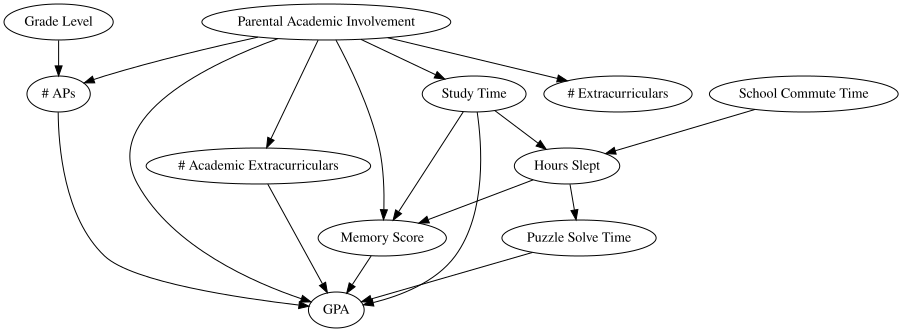

In [ ]:
smart = gv.Digraph(name="StatsProj")

smart.node('A','GPA')
smart.node('B','Grade Level')
smart.node('C','# APs')
smart.node('D','School Commute Time')
smart.node('E','Puzzle Solve Time')
smart.node('F','Memory Score')
smart.node('G','Parental Academic Involvement')
smart.node('H','Hours Slept')
smart.node('I','Study Time')
smart.node('J','# Extracurriculars')
smart.node('K','# Academic Extracurriculars')

smart.edges(['FA','CA','IA','KA','GA','EA','BC','DH','HE','IF','HF','GF','GJ','GK','IH','GC','GI'])

smart

I'd like to make a BART model, which is a little more complex than a simple GLM with bambi, but it's really good for analysis. Especially for our usecase with finding the the supposed importance of a given variable. It's good at pointing out interactions and the extent to which a variable is impactful.

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/AP%20Statistics%20Survey%20Responses%20-%20Form%20Responses%201.csv")

data

,Timestamp,Puzzle_Solve_Time,Memory_Score,Grade_Level,numAPs,Study_Time,NonAc_Extra_Count,NonAc_Extra_Time,Ac_Extra_Count,Ac_Extra_Time,Sleep_Time,Commute_Time,Parent_Involvement,GPA
0,5/14/2026 14:53:10,60,6,12,6,5.0,2,6.0,1,0.0,8.0,50,2,3.80
1,5/14/2026 15:00:15,133,5,11,7,5.0,3,10.0,0,0.0,8.0,30,1,3.60
2,5/14/2026 15:08:30,20,12,11,6,3.0,3,13.0,1,1.0,7.0,70,2,3.70
3,5/14/2026 15:18:50,126,14,12,5,2.0,0,0.0,0,0.0,6.0,45,1,3.70
4,5/14/2026 15:24:38,40,14,11,6,1.0,3,16.0,0,0.0,7.0,40,1,3.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,5/18/2026 9:47:41,30,6,11,5,4.0,3,2.0,0,0.0,7.0,40,1,3.60
57,5/18/2026 9:49:23,28,8,11,4,12.0,3,10.0,1,5.0,6.0,30,2,3.70
58,5/18/2026 9:49:55,12,9,10,2,2.0,2,20.0,1,1.0,7.0,40,2,3.69
59,5/18/2026 9:55:09,87,3,10,1,4.0,1,5.0,0,0.0,6.0,55,1,3.65


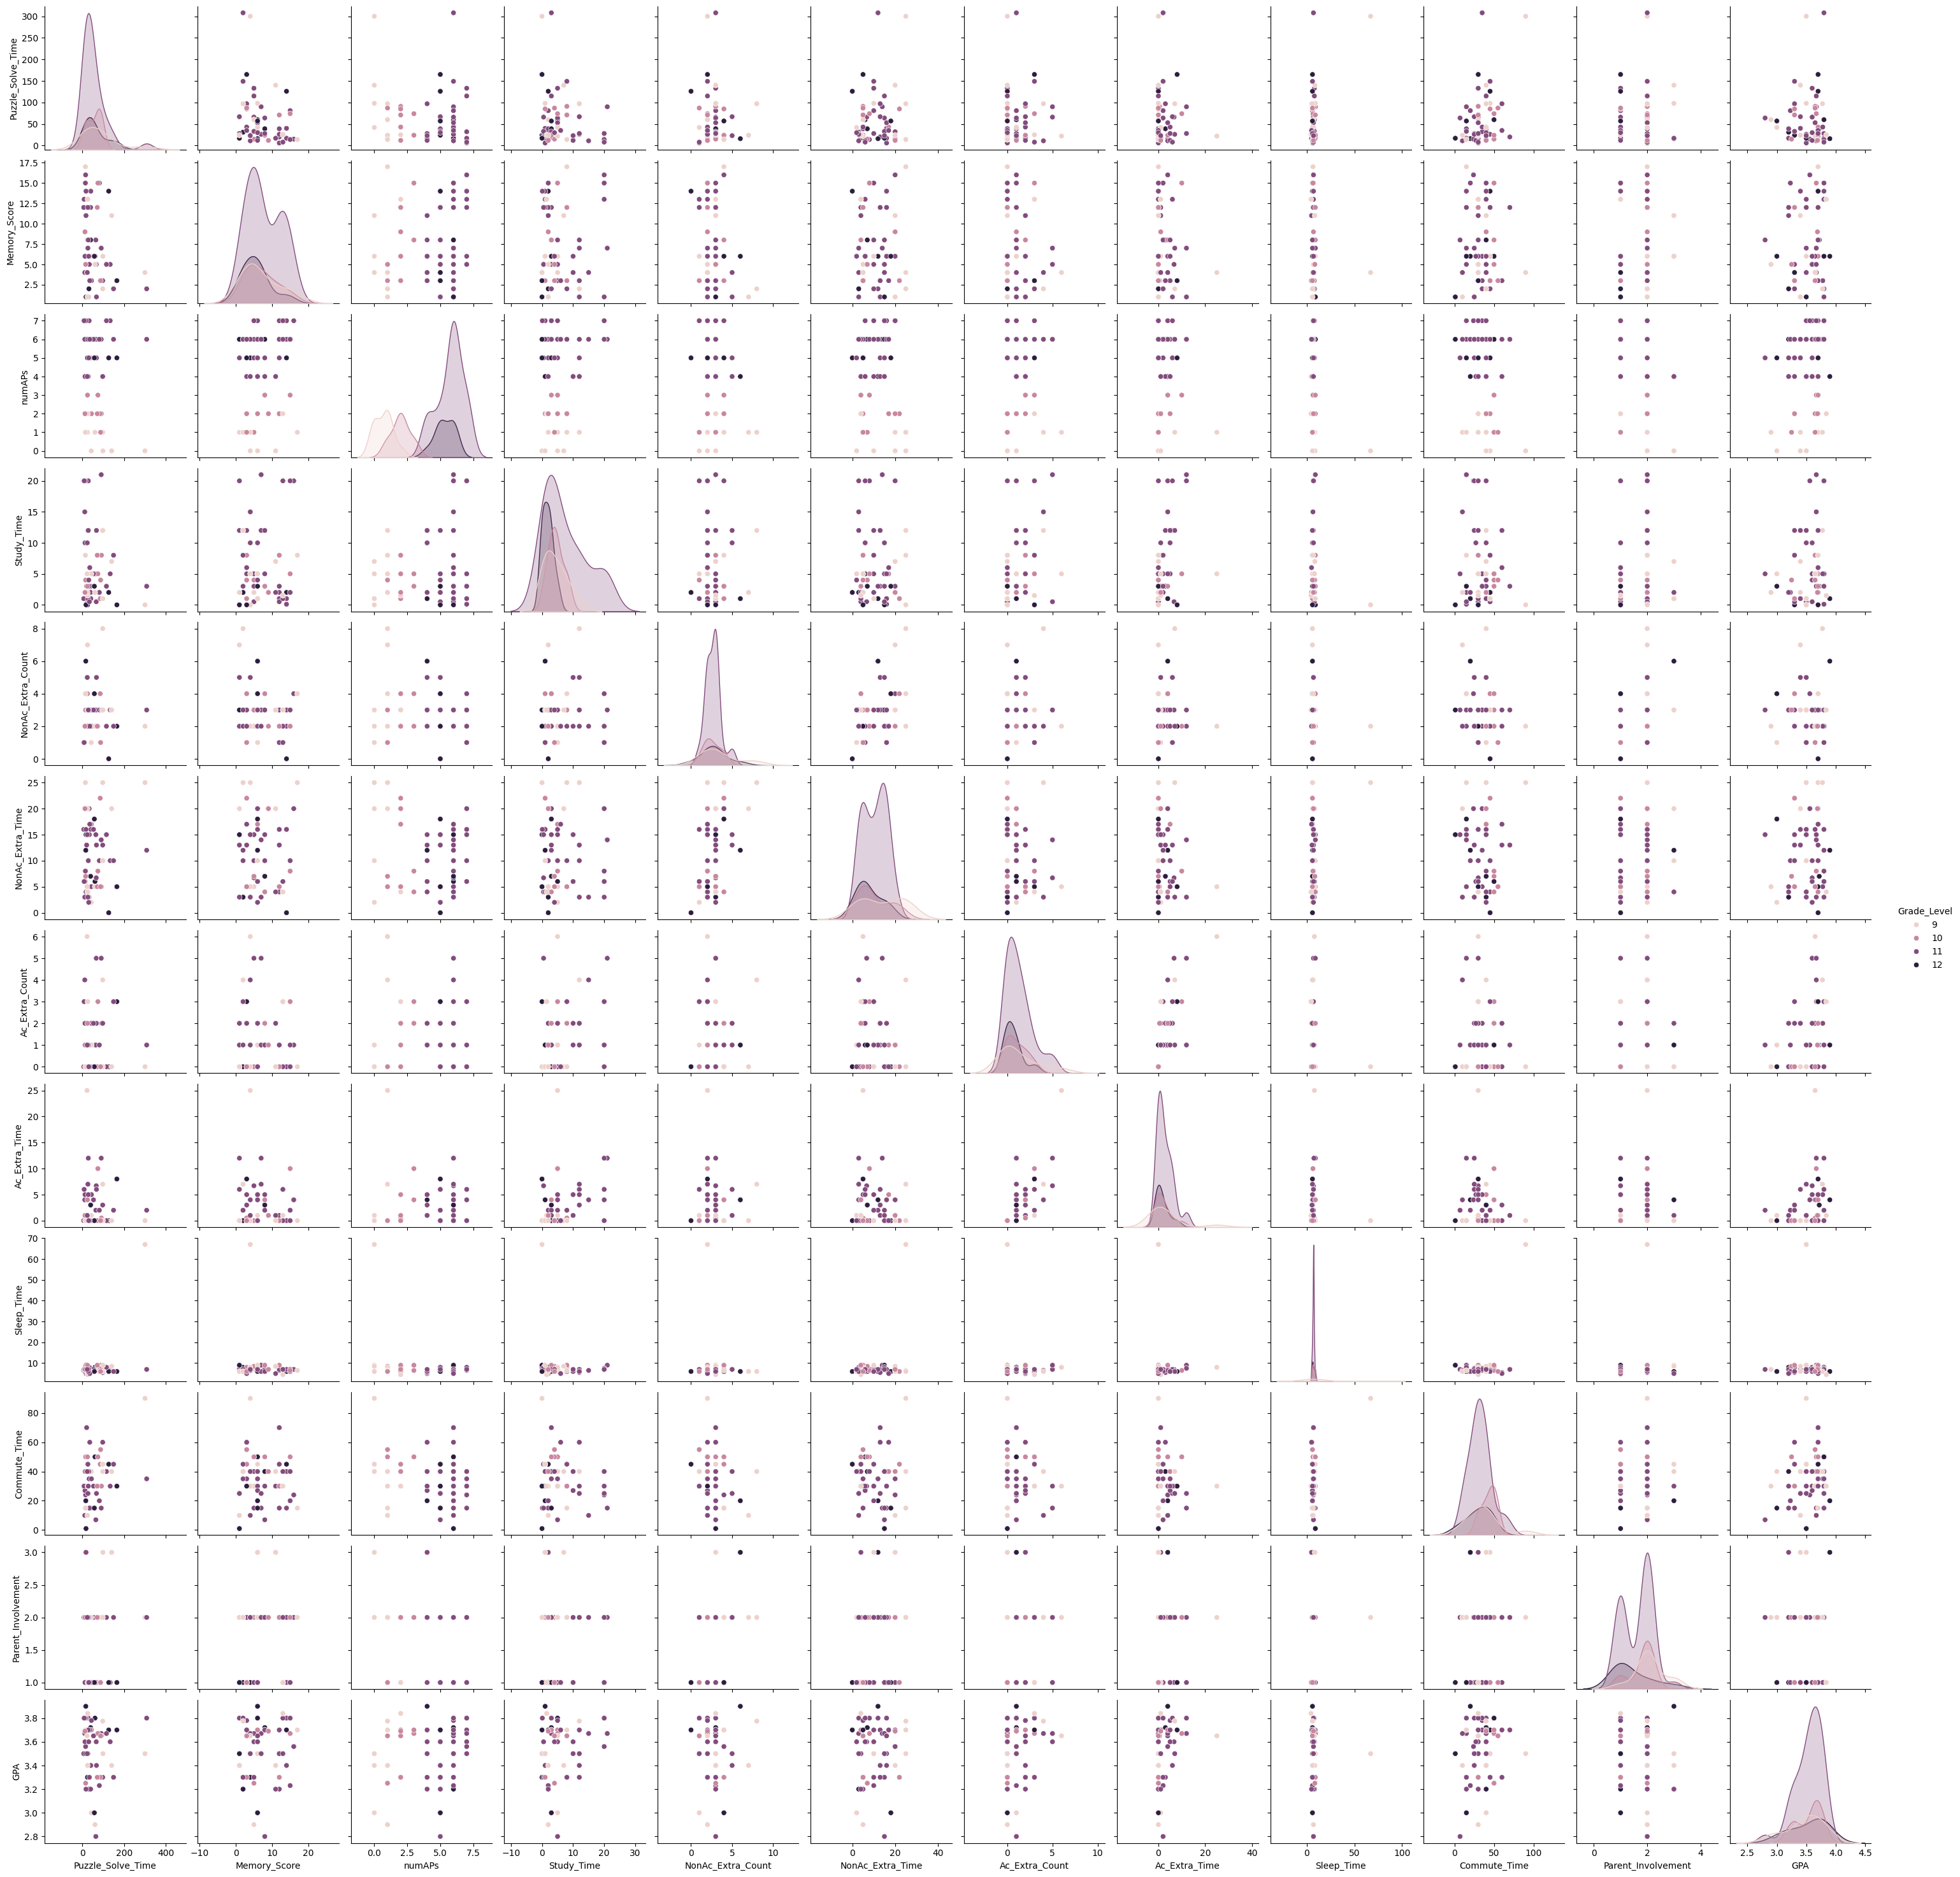

In [ ]:
sns.pairplot(data, hue='Grade_Level')

In [ ]:
X = data[['Parent_Involvement','Commute_Time','Sleep_Time','Ac_Extra_Count','NonAc_Extra_Count','Study_Time','numAPs','Memory_Score','Puzzle_Solve_Time']]

Y = data['GPA']

In [ ]:
with pm.Model() as model_smart:
    s = pm.HalfNormal('s',0.55)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties = pm.sample(compute_convergence_checks=False)

In [ ]:
SEED=42

In [ ]:
with model_smart:
    dt = ":pm.sample(idata_kwargs={"log_likelihood True}, random_seed=SEED)
    pm .sample_posterior_predictive(dt, random_seed=SEED, extend_inferencedata=True)

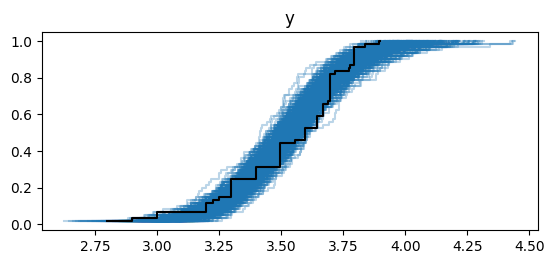

In [ ]:
az.plot_ppc_dist(dt, num_samples=400);

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='Parent_Involvement'>, <Axes: xlabel='Commute_Time'>,
       <Axes: xlabel='Sleep_Time'>, <Axes: xlabel='Ac_Extra_Count'>,
       <Axes: xlabel='NonAc_Extra_Count'>, <Axes: xlabel='Study_Time'>,
       <Axes: xlabel='numAPs'>, <Axes: xlabel='Memory_Score'>,
       <Axes: xlabel='Puzzle_Solve_Time'>], dtype=object)

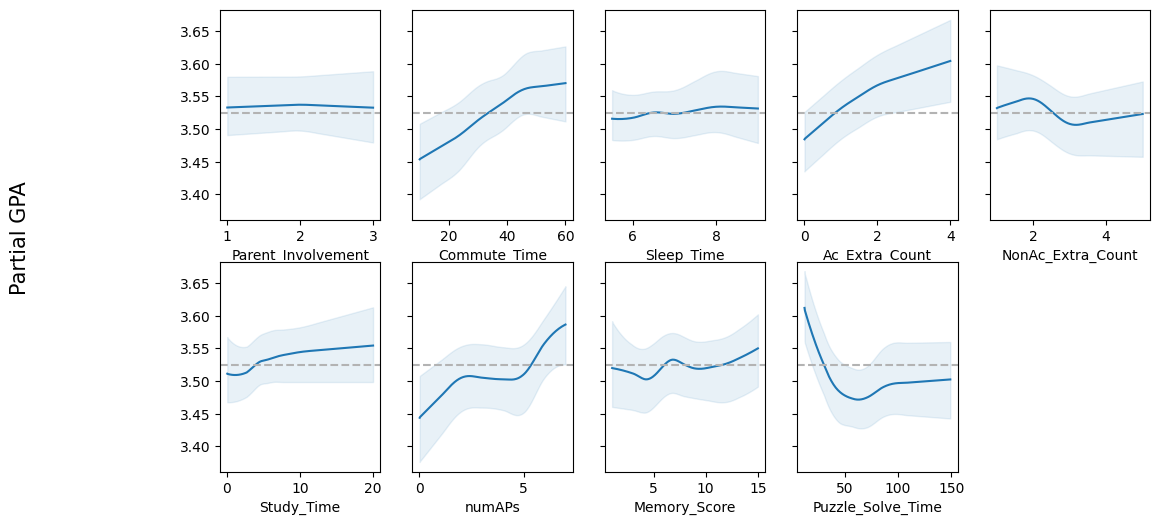

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='Parent_Involvement'>, <Axes: xlabel='Commute_Time'>,
       <Axes: xlabel='Sleep_Time'>, <Axes: xlabel='Ac_Extra_Count'>,
       <Axes: xlabel='NonAc_Extra_Count'>, <Axes: xlabel='Study_Time'>,
       <Axes: xlabel='numAPs'>, <Axes: xlabel='Memory_Score'>,
       <Axes: xlabel='Puzzle_Solve_Time'>], dtype=object)

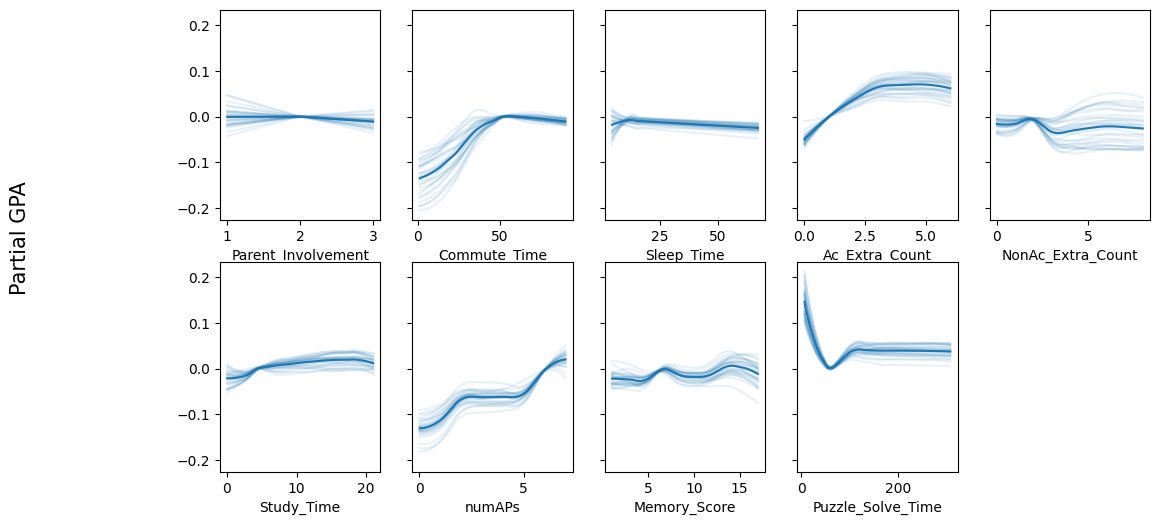

In [ ]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [ ]:
model_hyp = bmb.Model("GPA ~ Grade_Level:numAPs + Parent_Involvement:numAPs + Parent_Involvement + Parent_Involvement:Ac_Extra_Count + Parent_Involvement:Memory_Score + Parent_Involvement:Study_Time + Parent_Involvement:Study_Time:Memory_Score + Parent_Involvement:Study_Time:Sleep_Time:Memory_Score + Parent_Involvement:Study_Time:Sleep_Time:Puzzle_Solve_Time + Parent_Involvement:NonAc_Extra_Count:Sleep_Time:Memory_Score + Parent_Involvement:NonAc_Extra_Count:Sleep_Time:Puzzle_Solve_Time + Commute_Time:Sleep_Time:Memory_Score + Commute_Time:Sleep_Time:Puzzle_Solve_Time", data = data)
idata_hyp = model_hyp.fit(idata_kwargs={"log_likelihood":True})
model_nointer = bmb.Model("GPA ~ numAPs + Parent_Involvement + Ac_Extra_Count + Memory_Score + Study_Time + Memory_Score + Puzzle_Solve_Time + Sleep_Time", data = data)
idata_nointer = model_nointer.fit(idata_kwargs={"log_likelihood":True})
model_nopuzzle = bmb.Model("GPA ~ Grade_Level:numAPs + Parent_Involvement:numAPs + Parent_Involvement + Parent_Involvement:Ac_Extra_Count + Parent_Involvement:Memory_Score + Parent_Involvement:Study_Time + Parent_Involvement:Study_Time:Memory_Score + Parent_Involvement:Study_Time:Sleep_Time:Memory_Score + Parent_Involvement:NonAc_Extra_Count:Sleep_Time:Memory_Score + Commute_Time:Sleep_Time:Memory_Score", data = data)
idata_nopuzzle = model_nopuzzle.fit(idata_kwargs={"log_likelihood":True})
model_nomemory = bmb.Model("GPA ~ Grade_Level:numAPs + Parent_Involvement:numAPs + Parent_Involvement + Parent_Involvement:Ac_Extra_Count + Parent_Involvement:Study_Time + Parent_Involvement:Study_Time + Parent_Involvement:Study_Time:Sleep_Time + Parent_Involvement:Study_Time:Sleep_Time:Puzzle_Solve_Time + Parent_Involvement:NonAc_Extra_Count:Sleep_Time + Parent_Involvement:NonAc_Extra_Count:Sleep_Time:Puzzle_Solve_Time + Commute_Time:Sleep_Time + Commute_Time:Sleep_Time:Puzzle_Solve_Time", data = data)
idata_nomemory = model_nomemory.fit(idata_kwargs={"log_likelihood":True})
model_nostudy = bmb.Model("GPA ~ Grade_Level:numAPs + Parent_Involvement:numAPs + Parent_Involvement + Parent_Involvement:Ac_Extra_Count + Parent_Involvement:Memory_Score + Parent_Involvement:Memory_Score + Parent_Involvement:Sleep_Time:Memory_Score + Parent_Involvement:Sleep_Time:Puzzle_Solve_Time + Parent_Involvement:NonAc_Extra_Count:Sleep_Time + Parent_Involvement:NonAc_Extra_Count:Sleep_Time:Puzzle_Solve_Time + Commute_Time:Sleep_Time + Commute_Time:Sleep_Time:Puzzle_Solve_Time", data = data)
idata_nostudy = model_nostudy.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
model_onlypuzzle = bmb.Model("GPA ~ Puzzle_Solve_Time", data = data)
idata_onlypuzzle = model_onlypuzzle.fit(idata_kwargs={"log_likelihood":True})
model_onlymemory = bmb.Model("GPA ~ Memory_Score", data = data)
idata_onlymemory = model_onlymemory.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
cmp_df = az.compare({"Our Hypothesis":idata_hyp,"No Interactions":idata_nointer,"No Puzzle Solve Time":idata_nopuzzle,"Only Puzzle Solve Time":idata_onlypuzzle,"No Memory Score":idata_nomemory,"No Study Time":idata_nostudy})

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo

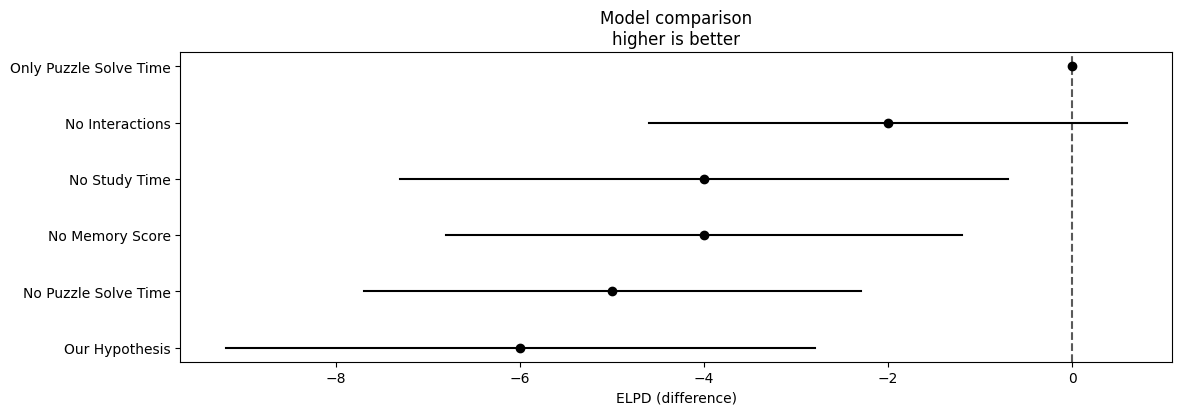

In [ ]:
az.plot_compare(cmp_df)